# Iris
### sepal: 萼片,   petal: 花瓣

##### data from: https://www.kaggle.com/uciml/iris/data
##### code modified from: https://www.kaggle.com/pratik2901/sequential-ann-and-visualization

In [1]:
import warnings
warnings.simplefilter(action='ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

In [2]:
tf.__version__

'2.13.0'

In [3]:
seed = 5
np.random.seed(seed)

In [4]:
iris = pd.read_csv("../input/Iris.csv")

In [5]:
iris.head()  # .head gives the first 5 rows

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
col = iris.columns       # .columns gives columns names in data 
print(col)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


# **Visualization**

In [7]:
iris["Species"].value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: Species, dtype: int64

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

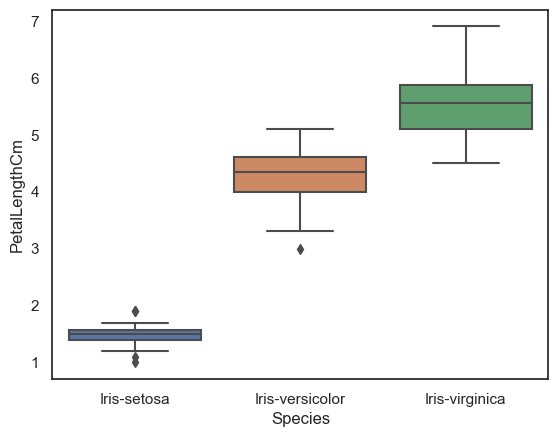

In [8]:
sns.set(style='white', color_codes=True)
sns.boxplot(x="Species", y="PetalLengthCm", data=iris)

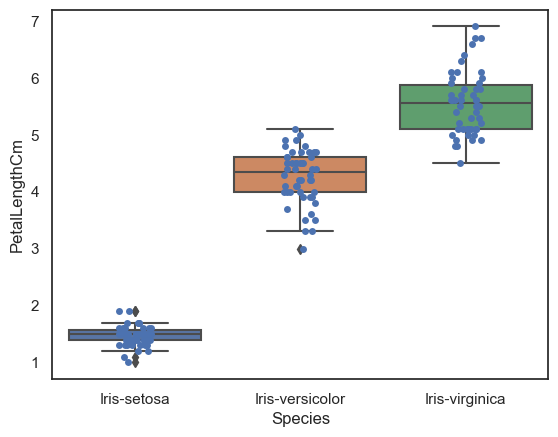

In [9]:
ax = sns.boxplot(x="Species", y="PetalLengthCm", data=iris)
ax = sns.stripplot(x="Species", y="PetalLengthCm", data=iris, jitter=True, edgecolor="gray")

array([[<Axes: title={'center': 'PetalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'PetalWidthCm'}, xlabel='[Species]'>],
       [<Axes: title={'center': 'SepalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'SepalWidthCm'}, xlabel='[Species]'>]],
      dtype=object)

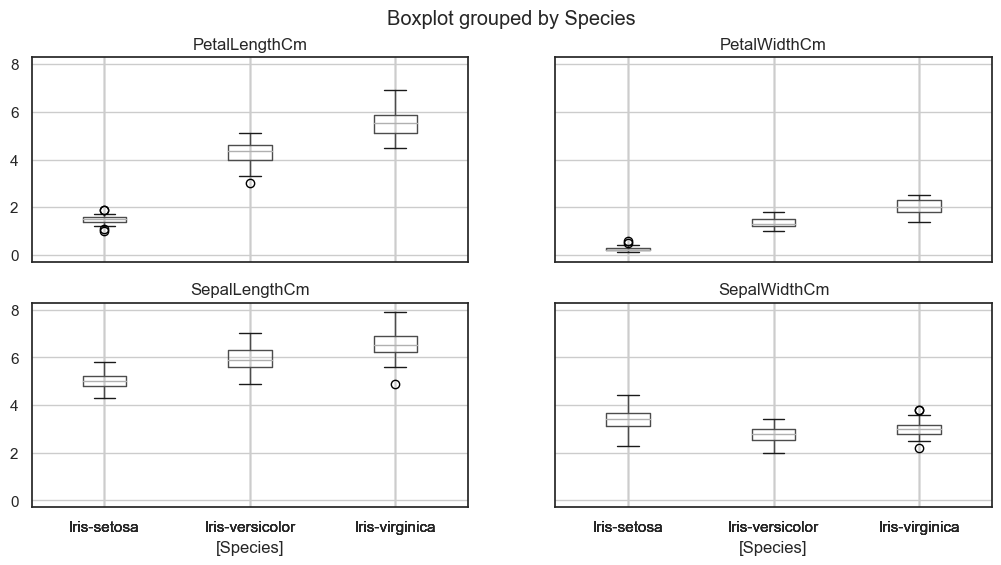

In [10]:
iris.drop("Id", axis=1).boxplot(by="Species", figsize=(12, 6))

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

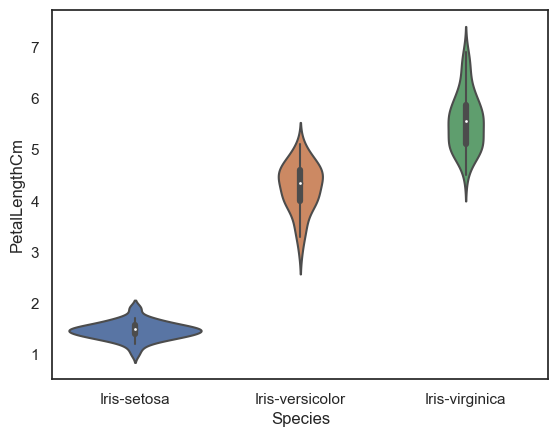

In [11]:
sns.violinplot(x="Species", y="PetalLengthCm", data=iris, size=6)

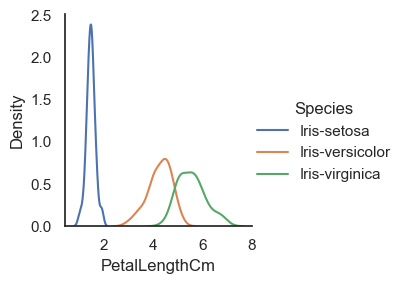

In [12]:
sns.FacetGrid(iris, hue="Species") \
   .map(sns.kdeplot, "PetalLengthCm") \
   .add_legend()

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

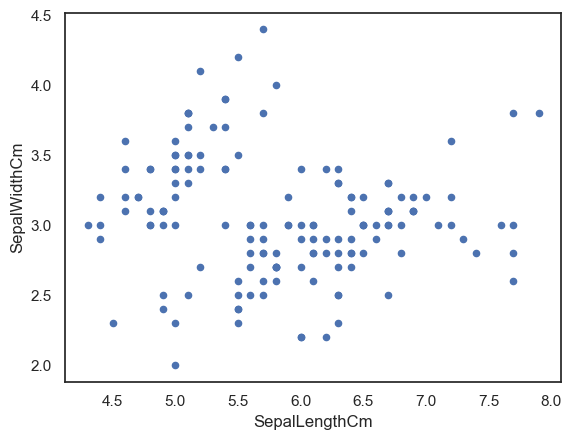

In [13]:
iris.plot.scatter(x="SepalLengthCm", y="SepalWidthCm")

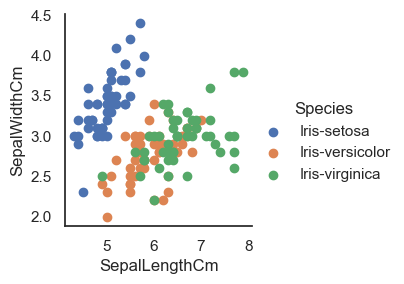

In [14]:
sns.FacetGrid(iris, hue="Species") \
   .map(plt.scatter, "SepalLengthCm", "SepalWidthCm") \
   .add_legend()

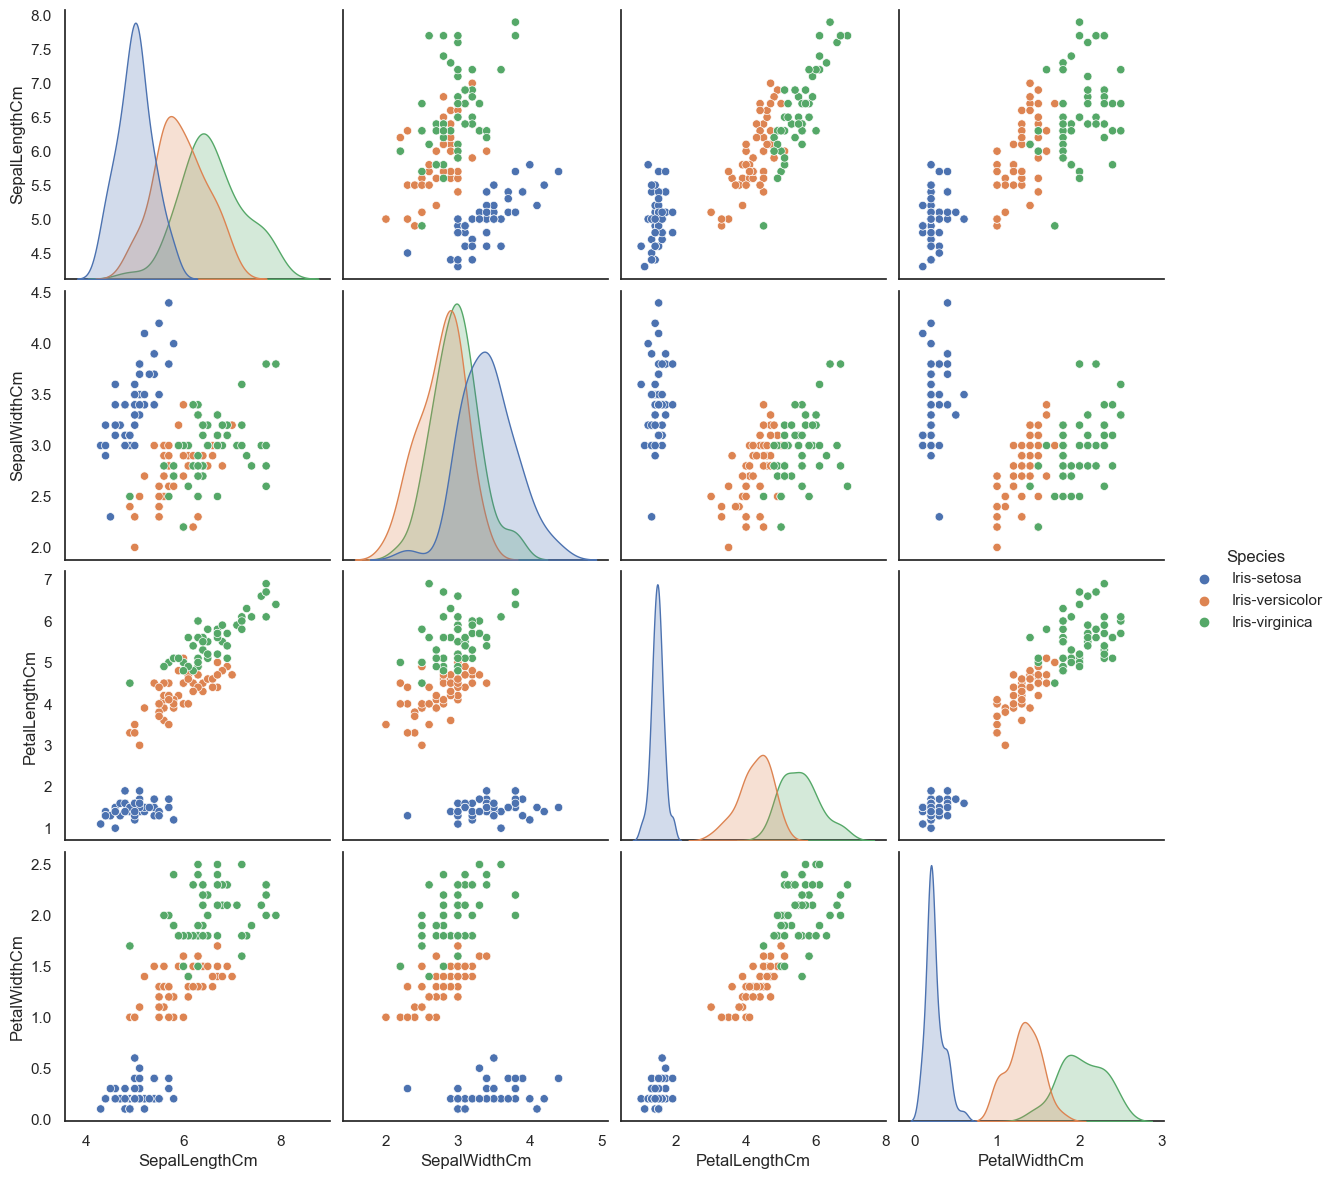

In [15]:
sns.pairplot(iris.drop("Id", axis=1), hue="Species", size=3, diag_kind="kde")

# **Label Encoding**

In [16]:
dataset = iris.values
X = dataset[:,1:5].astype(float)
print(X[0:5,:])
#print(X)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [17]:
# convert text into vectors
# method #1
Y = dataset[:,5]
print(Y)

['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor

In [18]:
Y_df = pd.DataFrame(Y)
print(Y_df)

                  0
0       Iris-setosa
1       Iris-setosa
2       Iris-setosa
3       Iris-setosa
4       Iris-setosa
..              ...
145  Iris-virginica
146  Iris-virginica
147  Iris-virginica
148  Iris-virginica
149  Iris-virginica

[150 rows x 1 columns]


In [19]:
Y_onehot = pd.get_dummies(Y_df)
print(Y_onehot)

     0_Iris-setosa  0_Iris-versicolor  0_Iris-virginica
0                1                  0                 0
1                1                  0                 0
2                1                  0                 0
3                1                  0                 0
4                1                  0                 0
..             ...                ...               ...
145              0                  0                 1
146              0                  0                 1
147              0                  0                 1
148              0                  0                 1
149              0                  0                 1

[150 rows x 3 columns]


In [20]:
# convert text into vectors
# method #2
Y = dataset[:,5]
encoder = LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)
print(Y[0:5])
print(encoded_Y)

['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [21]:
answer_Y = tf.keras.utils.to_categorical(encoded_Y)
print(answer_Y[0:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


# **Sequential Based ANN **

In [22]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(8, input_dim=4, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(3, activation=tf.nn.softmax))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 40        
                                                                 
 dense_1 (Dense)             (None, 3)                 27        
                                                                 
Total params: 67 (268.00 Byte)
Trainable params: 67 (268.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
history = model.fit(X,answer_Y,epochs=60,batch_size=5)

Epoch 1/60
30/30 [==============================] - 1s 1ms/step - loss: 0.9541 - accuracy: 0.3200
Epoch 2/60
30/30 [==============================] - 0s 1ms/step - loss: 0.8389 - accuracy: 0.3067
Epoch 3/60
30/30 [==============================] - 0s 1ms/step - loss: 0.7836 - accuracy: 0.4267
Epoch 4/60
30/30 [==============================] - 0s 1ms/step - loss: 0.7406 - accuracy: 0.3867
Epoch 5/60
30/30 [==============================] - 0s 1ms/step - loss: 0.7011 - accuracy: 0.4067
Epoch 6/60
30/30 [==============================] - 0s 1ms/step - loss: 0.6725 - accuracy: 0.4000
Epoch 7/60
30/30 [==============================] - 0s 1ms/step - loss: 0.6521 - accuracy: 0.3933
Epoch 8/60
30/30 [==============================] - 0s 1ms/step - loss: 0.6334 - accuracy: 0.4267
Epoch 9/60
30/30 [==============================] - 0s 1ms/step - loss: 0.6169 - accuracy: 0.4667
Epoch 10/60
30/30 [==============================] - 0s 1ms/step - loss: 0.6023 - accuracy: 0.4733
Epoch 11/60
30/30 [

有的版本用 acc and val_acc, 有的版本用 accuracy and val_accuracy.

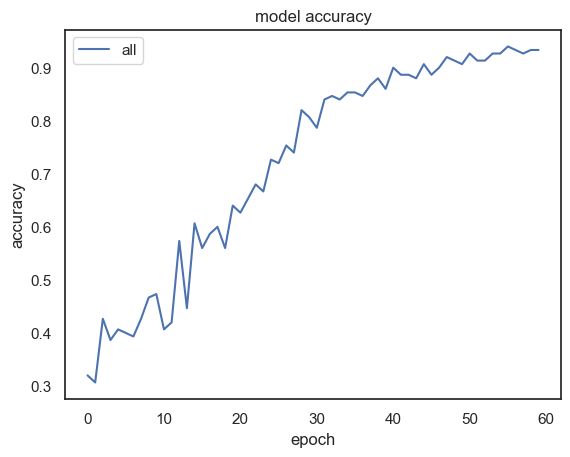

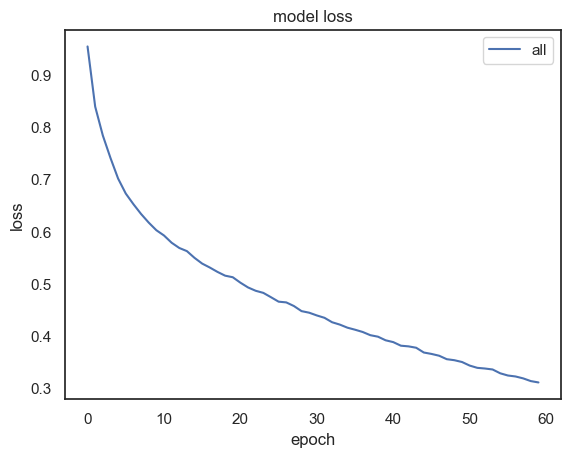

In [25]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['all'], loc='upper left')
plt.savefig('acc.png')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['all'], loc='upper right')
plt.savefig('loss.png')
plt.show()

In [26]:
scores = model.evaluate(X,answer_Y)

5/5 [==============================] - 0s 2ms/step - loss: 0.3055 - accuracy: 0.9467


In [27]:
print("Accuracy:%.2f%%"%(scores[1]*100))

Accuracy:94.67%


In [28]:
predict_probability = model.predict(X) 
prediction = np.argmax(predict_probability,axis=1)
print(prediction)

5/5 [==============================] - 0s 1ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 1 2 2 1 2 2 2 2 2 2
 2 2]


In [29]:
print(encoded_Y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [30]:
pd.crosstab(encoded_Y,prediction,rownames=['label'],colnames=['predict'])

predict,0,1,2
label,,,
0,50,0,0
1,0,46,4
2,0,4,46
